# DETR (DEtection TRansformer) from Scratch

A simplified DETR ([Carion et al., 2020](https://arxiv.org/abs/2005.12872)) trained on the [CPPE-5](https://huggingface.co/datasets/rishitdagli/cppe-5) medical PPE detection dataset (coverall, face shield, gloves, goggles, mask).

What's in this notebook:
- **Box utilities**: IoU, Generalized IoU, and Distance IoU written by hand, with a unit test
- **Dataset pipeline**: COCO `xywh` boxes converted to normalized `cxcywh`, with a custom collate function for variable object counts
- **Model**: patch tokens from a 16x16 conv, learnable positional embeddings, 200 learnable object queries, an encoder-decoder transformer, and separate class and box heads
- **Hungarian matching**: bipartite matching of predictions to ground truth using class, L1, and GIoU costs
- **Set loss**: cross-entropy (with a "no object" class) plus L1 and GIoU box losses on matched pairs
- **Matching visualization** every 2 epochs, so you can watch queries lock onto objects

Differences from the paper: there's no CNN backbone (patches go straight into the transformer), the encoder-decoder uses PyTorch's `nn.Transformer`, and there are no auxiliary decoder losses.

## Setup

In [ ]:
# Colab already has these; uncomment locally if needed
# !pip install torch torchvision datasets scipy matplotlib

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Box utilities

In [ ]:
def box_iou(boxes1, boxes2):
    top_x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    top_y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    bot_x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    bot_y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    w = (bot_x2 - top_x1).clamp(min=0)
    h = (bot_y2 - top_y1).clamp(min=0)
    intersection = w * h                                    # (N, M)

    A = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])  # (N,)
    B = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])  # (M,)
    union = A[:, None] + B[None, :] - intersection          # (N, M)

    return intersection / union.clamp(min=1e-7)

In [ ]:
a = torch.tensor([[0., 0., 10., 10.]])
b = torch.tensor([[0., 0., 10., 10.], [5., 5., 15., 15.], [20., 20., 30., 30.]])
print(box_iou(a, b))
print(a.shape)
print(b.shape)
# expect [[1.0, 0.1429, 0.0]]
assert torch.allclose(box_iou(a, b), torch.tensor([[1.0, 25/175, 0.0]]), atol=1e-4)
assert box_iou(torch.zeros(0, 4), b).shape == (0, 3)


tensor([[1.0000, 0.1429, 0.0000]])
torch.Size([1, 4])
torch.Size([3, 4])


In [ ]:
def generalized_box_iou(boxes1, boxes2):
  # Top_left
  top_x = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
  top_y = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
  # Bot_right
  bot_x = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
  bot_y = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

  h = (bot_y - top_y).clamp(min=0)
  w = (bot_x - top_x).clamp(min=0)

  intersection = w * h

  A = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
  B = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
  union = A[:, None] + B[None, :] - intersection
  iou = intersection / union.clamp(min=1e-7)

  # enclosing box: min of top-lefts, max of bottom-rights
  enc_x1 = torch.min(boxes1[:, None, 0], boxes2[None, :, 0])
  enc_y1 = torch.min(boxes1[:, None, 1], boxes2[None, :, 1])
  enc_x2 = torch.max(boxes1[:, None, 2], boxes2[None, :, 2])
  enc_y2 = torch.max(boxes1[:, None, 3], boxes2[None, :, 3])

  C = (enc_x2 - enc_x1) * (enc_y2 - enc_y1)

  return iou - (C - union) / C.clamp(min=1e-7)

def diou(boxes1, boxes2):
    iou = box_iou(boxes1, boxes2)

    c1x = (boxes1[:, 0] + boxes1[:, 2]) / 2
    c1y = (boxes1[:, 1] + boxes1[:, 3]) / 2
    c2x = (boxes2[:, 0] + boxes2[:, 2]) / 2
    c2y = (boxes2[:, 1] + boxes2[:, 3]) / 2

    d2 = (c1x[:, None] - c2x[None, :]) ** 2 + (c1y[:, None] - c2y[None, :]) ** 2

    enc_x1 = torch.min(boxes1[:, None, 0], boxes2[None, :, 0])
    enc_y1 = torch.min(boxes1[:, None, 1], boxes2[None, :, 1])
    enc_x2 = torch.max(boxes1[:, None, 2], boxes2[None, :, 2])
    enc_y2 = torch.max(boxes1[:, None, 3], boxes2[None, :, 3])
    c2 = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2

    return iou - d2 / c2.clamp(min=1e-7)



## Dataset: CPPE-5

In [6]:
import torch
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import torchvision.transforms as T

IMG_SIZE = 256   # 256/16 = 16x16 = 256 patches, matches your pos_embed

class DetectionDataset(Dataset):
    def __init__(self, hf_split, img_size=IMG_SIZE):
        self.ds = hf_split
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"].convert("RGB")
        W, H = img.size

        boxes = torch.tensor(item["objects"]["bbox"], dtype=torch.float32)  # COCO: x, y, w, h (pixels)
        labels = torch.tensor(item["objects"]["category"], dtype=torch.long)

        # COCO xywh -> normalized cxcywh
        x, y, w, h = boxes.unbind(-1)
        boxes = torch.stack([(x + w / 2) / W, (y + h / 2) / H, w / W, h / H], dim=-1)
        boxes = boxes.clamp(0, 1)   # a few CPPE-5 boxes slightly exceed image bounds

        return self.transform(img), {"labels": labels, "boxes": boxes}


def collate_fn(batch):
    # images stack, targets stay a list since each image has a different number of objects
    images = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return images, targets


hf = load_dataset("rishitdagli/cppe-5")
train_ds = DetectionDataset(hf["train"])
test_ds = DetectionDataset(hf["test"])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=2)

NUM_CLASSES = 5   # coverall, face shield, gloves, goggles, mask
# model = DeTr(num_classes=NUM_CLASSES + 1)   # +1 for "no object"

images, targets = next(iter(train_loader))
print(images.shape)                 # (8, 3, 256, 256)
print(targets[0]["boxes"].shape)    # (num_objects, 4)
print(targets[0]["labels"])

torch.Size([8, 3, 256, 256])
torch.Size([10, 4])
tensor([4, 4, 1, 1, 2, 2, 2, 2, 0, 0])


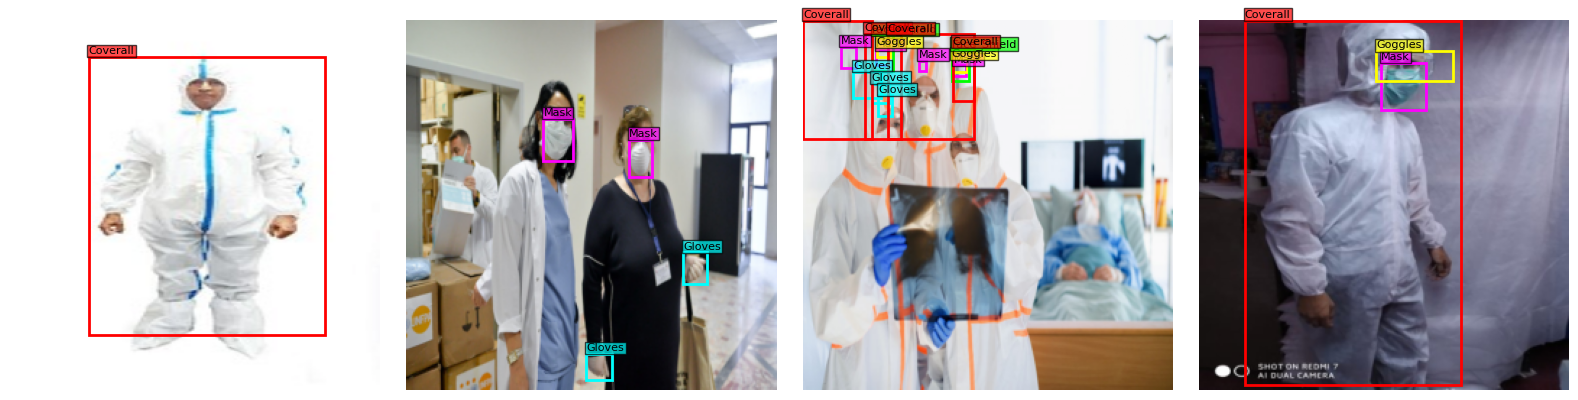

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_NAMES = ["Coverall", "Face_Shield", "Gloves", "Goggles", "Mask"]
COLORS = ["red", "lime", "cyan", "yellow", "magenta"]

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_batch(images, targets, n=4):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for i, ax in enumerate(axes):
        img = (images[i].cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0)
        ax.imshow(img)

        H, W = img.shape[:2]
        for (cx, cy, w, h), label in zip(targets[i]["boxes"], targets[i]["labels"]):
            x0, y0 = (cx - w / 2) * W, (cy - h / 2) * H   # cxcywh -> top-left corner in pixels
            c = COLORS[label]
            ax.add_patch(patches.Rectangle((x0, y0), w * W, h * H, fill=False, edgecolor=c, linewidth=2))
            ax.text(x0, y0 - 2, CLASS_NAMES[label], color="black", fontsize=8,
                    bbox=dict(facecolor=c, alpha=0.7, pad=1))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

images, targets = next(iter(train_loader))
show_batch(images, targets)

## Model

In [34]:
class PatchTokens(nn.Module):
  def __init__(self, in_channels=3):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, 768, kernel_size=16,stride=16)
  def forward(self, x): # B, C, H, W -> B, 768, 16,16
    return self.conv(x).flatten(2).permute(0,2,1)


class ObjectHead(nn.Module):
  def __init__(self, num_classes, hdim=768):
    super().__init__()
    self.task_head = nn.Sequential(
        nn.Linear(768,256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
  def forward(self, x):
    x = self.task_head(x)
    return x

class BoundingBoxHead(nn.Module):
  def __init__(self, hdim=768):
    super().__init__()
    self.task_head = nn.Sequential(
        nn.Linear(768,256),
        nn.ReLU(),
        nn.Linear(256, 4)
    )
  def forward(self, x):
    x = self.task_head(x)
    return x

class DeTr(nn.Module):
  def __init__(self, num_classes, hdim=768):
    super().__init__()

    self.patch_tokens = PatchTokens(3)
    self.learnable_queries = nn.Parameter(torch.randn(1,200,768))
    self.enc_dec = nn.Transformer(d_model=768, nhead=8, num_encoder_layers=3, num_decoder_layers=3,
                                  dim_feedforward=2048, dropout=0.1, batch_first=True)
    self.object_classification_head = ObjectHead(num_classes, hdim)
    self.bbox_head = BoundingBoxHead()
    self.pos_embed = nn.Parameter(torch.randn(1, 256, 768) * 0.02)

  def forward(self, x):
    B, C, H, W = x.shape
    queries = self.learnable_queries.repeat(B,1,1)
    x = self.patch_tokens(x) + self.pos_embed
    x = self.enc_dec(x,queries)

    cls_logits = self.object_classification_head(x)
    bbox_preds = self.bbox_head(x).sigmoid()

    return cls_logits, bbox_preds



In [35]:
detr = DeTr(num_classes=5+1)


## Optimizer and loss setup

In [36]:
import  torch.optim as optim
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_convert, generalized_box_iou, generalized_box_iou_loss
import torch.nn.functional as F

optimizer = optim.AdamW(detr.parameters(), lr=1e-4, weight_decay=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# criterion1 = nn.CrossEntropyLoss()
# criterion2 = nn.L1Loss()
# # criterion3 =
detr = detr.to(device)


## Hungarian matching

In [37]:
@torch.no_grad()
def hungarian_match(logits, boxes, gt_labels, gt_boxes):
  probs = torch.softmax(logits, dim=-1)
  cost_cls = -probs[:, gt_labels]                                   # (200, M)
  cost_l1 = torch.cdist(boxes, gt_boxes, p=1)                      # (200, M)
  cost_giou = -generalized_box_iou(box_convert(boxes, "cxcywh", "xyxy"),
                                     box_convert(gt_boxes, "cxcywh", "xyxy"))
  C = cost_cls + 5 * cost_l1 + 2 * cost_giou
  pred_idx, gt_idx = linear_sum_assignment(C.cpu().numpy())
  return torch.as_tensor(pred_idx, device=logits.device), torch.as_tensor(gt_idx, device=logits.device)

## Visualizing matches

In [38]:
vis_img, vis_tgt = train_ds[0]   # fixed image so you can compare across epochs

@torch.no_grad()
def show_matching(model, img, tgt, epoch):
    model.eval()
    logits, boxes = model(img.unsqueeze(0).to(device))
    model.train()
    logits, boxes = logits[0], boxes[0]
    probs = logits.softmax(-1)

    gt_labels, gt_boxes = tgt["labels"].to(device), tgt["boxes"].to(device)
    pred_idx, gt_idx = hungarian_match(logits, boxes, gt_labels, gt_boxes)

    im = (img * STD + MEAN).clamp(0, 1).permute(1, 2, 0)
    H, W = im.shape[:2]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(im)

    def draw(box, color, style, text):
        cx, cy, w, h = box.tolist()
        x0, y0 = (cx - w / 2) * W, (cy - h / 2) * H
        ax.add_patch(patches.Rectangle((x0, y0), w * W, h * H, fill=False,
                                       edgecolor=color, linewidth=2, linestyle=style))
        ax.text(x0, y0 - 2, text, fontsize=8, bbox=dict(facecolor=color, alpha=0.7, pad=1))

    for i, (q, g) in enumerate(zip(pred_idx.tolist(), gt_idx.tolist())):
        c = COLORS[i % len(COLORS)]
        draw(gt_boxes[g], c, "-", f"GT {CLASS_NAMES[gt_labels[g]]}")
        pred_cls = probs[q].argmax().item()
        name = CLASS_NAMES[pred_cls] if pred_cls < NUM_CLASSES else "no-obj"
        draw(boxes[q], c, "--", f"q{q} {name} p={probs[q, gt_labels[g]]:.2f}")

    ax.set_title(f"Epoch {epoch}: solid = GT, dashed = matched query")
    ax.axis("off")
    plt.show()

## Training

epoch 0: avg loss 2.3667


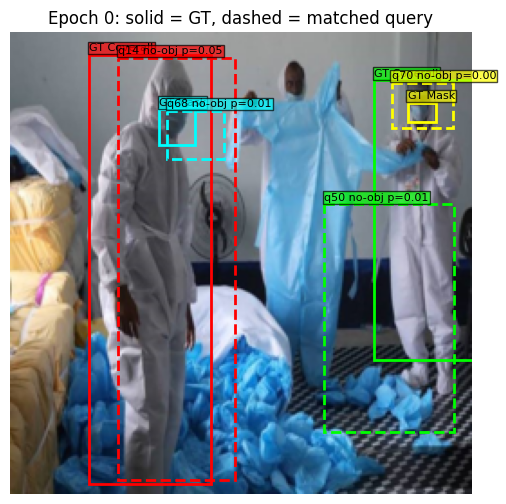

epoch 1: avg loss 2.5031
epoch 2: avg loss 2.3124


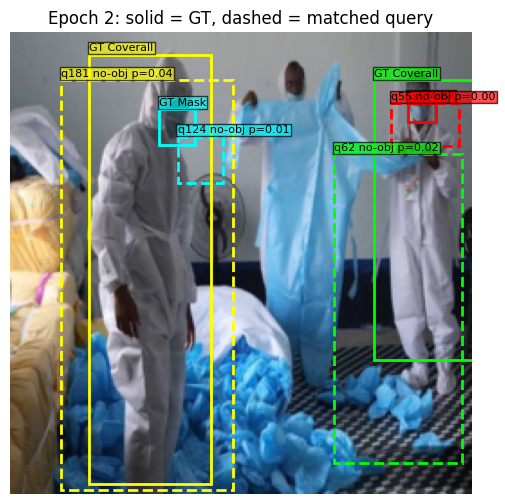

epoch 3: avg loss 2.3029
epoch 4: avg loss 2.2174


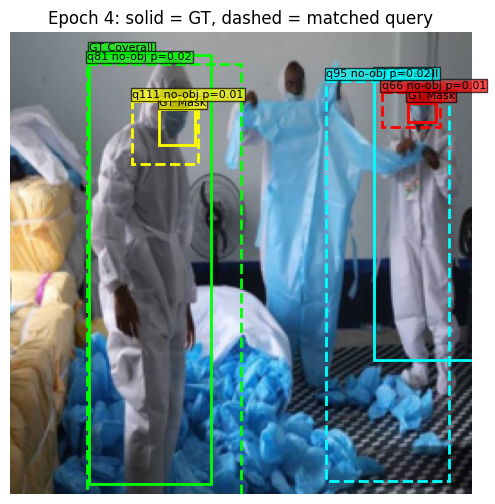

epoch 5: avg loss 2.2943
epoch 6: avg loss 2.3557


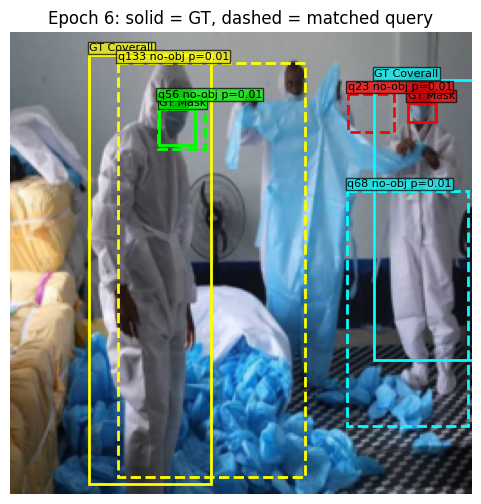

epoch 7: avg loss 2.2666
epoch 8: avg loss 2.2693


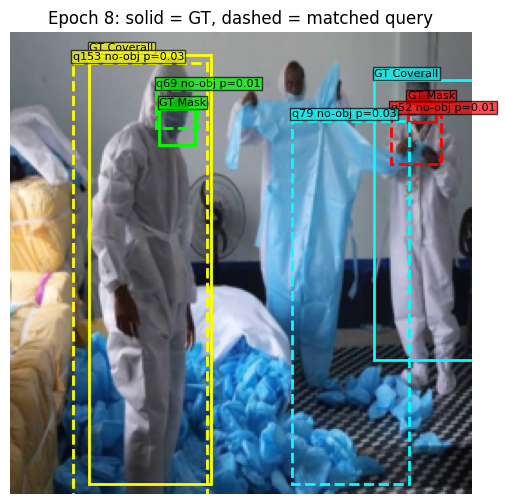

epoch 9: avg loss 2.2324
epoch 10: avg loss 2.2138


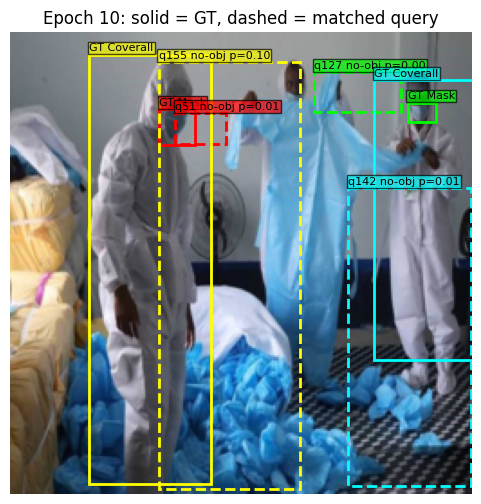

epoch 11: avg loss 2.2133
epoch 12: avg loss 2.1797


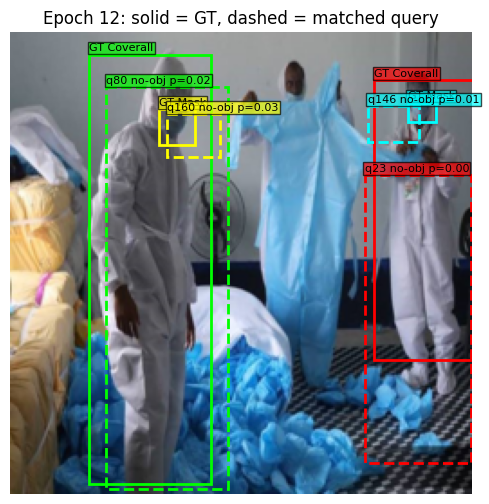

epoch 13: avg loss 2.1776
epoch 14: avg loss 2.2549


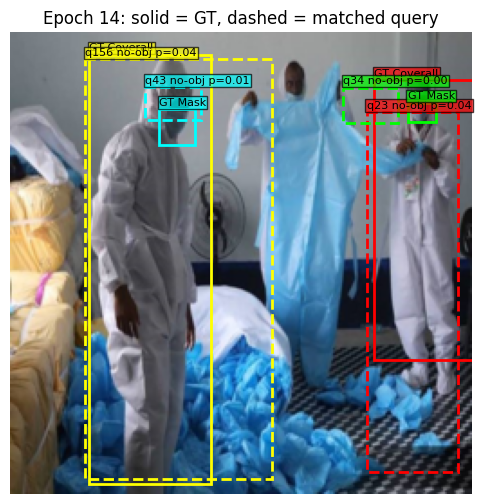

epoch 15: avg loss 2.2744
epoch 16: avg loss 2.1925


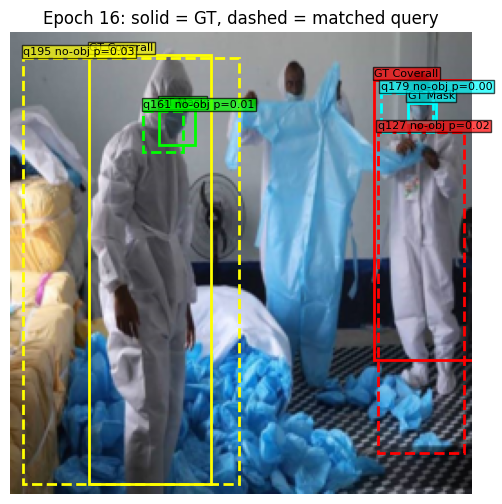

epoch 17: avg loss 2.2278
epoch 18: avg loss 2.1745


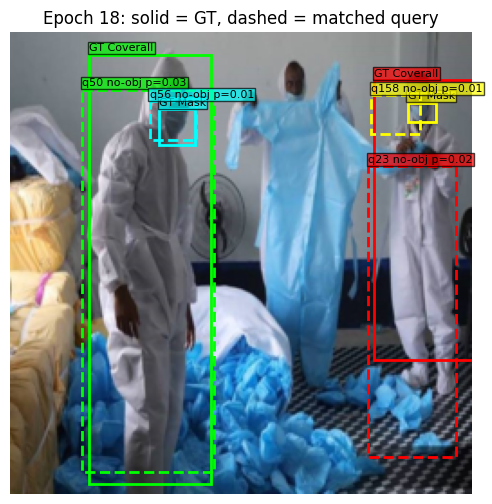

epoch 19: avg loss 2.1640
epoch 20: avg loss 2.1499


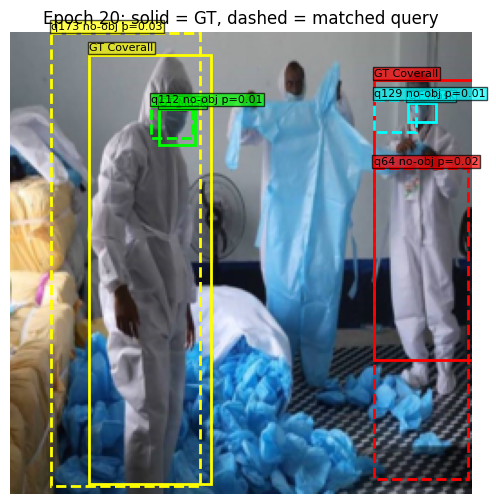

epoch 21: avg loss 2.1213
epoch 22: avg loss 2.2196


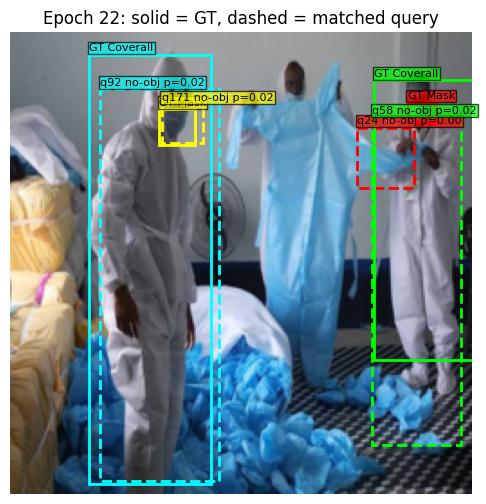

epoch 23: avg loss 2.2078
epoch 24: avg loss 2.2525


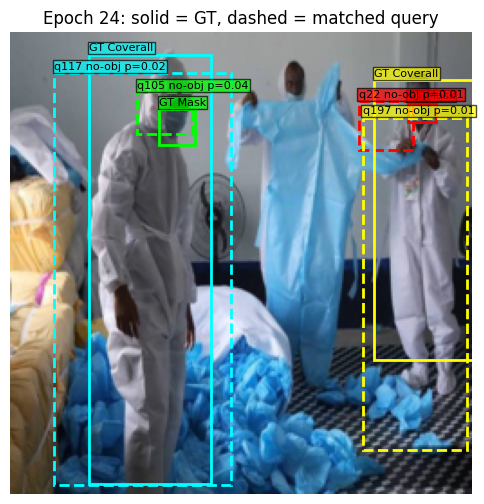

epoch 25: avg loss 2.2521
epoch 26: avg loss 2.2196


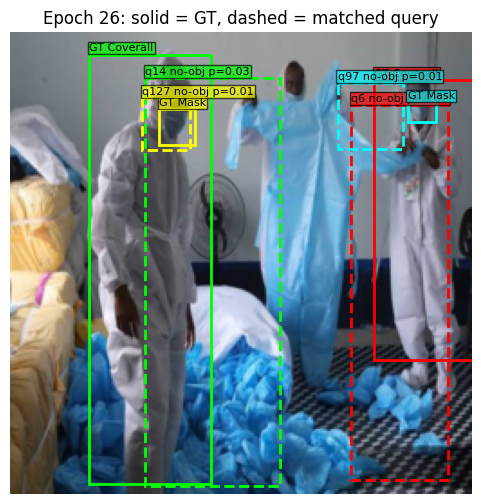

epoch 27: avg loss 2.2064
epoch 28: avg loss 2.1921


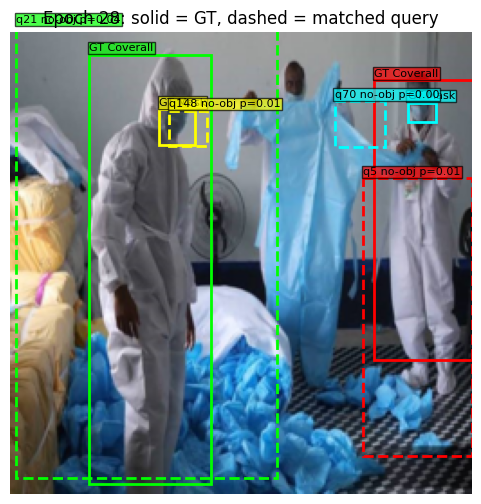

epoch 29: avg loss 2.2833


In [41]:
detr.train()
for epoch in range(30):
    total = 0
    for images, targets in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        pred_logits, pred_bbox = detr(images)

        loss = 0
        for b in range(images.shape[0]):
            class_labels = targets[b]["labels"].to(device)
            gt_bboxes = targets[b]["boxes"].to(device)
            target_cls = torch.full((pred_logits.shape[1],), NUM_CLASSES, dtype=torch.long, device=device)

            if len(class_labels) > 0:
                pred_idx, gt_idx = hungarian_match(pred_logits[b], pred_bbox[b], class_labels, gt_bboxes)
                target_cls[pred_idx] = class_labels[gt_idx]

                p, g = pred_bbox[b][pred_idx], gt_bboxes[gt_idx]
                loss_l1 = F.l1_loss(p, g, reduction="sum") / len(gt_idx)
                loss_giou = generalized_box_iou_loss(box_convert(p, "cxcywh", "xyxy"),
                                                     box_convert(g, "cxcywh", "xyxy"), reduction="mean")
                loss = loss + 5 * loss_l1 + 2 * loss_giou

            loss = loss + F.cross_entropy(pred_logits[b], target_cls)

        # per batch: inside the "for images, targets" loop
        loss = loss / images.shape[0]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(detr.parameters(), 0.1)
        optimizer.step()
        total += loss.item()

    # per epoch: inside "for epoch" only
    print(f"epoch {epoch}: avg loss {total / len(train_loader):.4f}")
    if epoch % 2 == 0:
        show_matching(detr, vis_img, vis_tgt, epoch)